In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_parquet('../data/processed/features.parquet')
df.shape

(2108, 19)

In [6]:
df.describe()

,score,spend_total,spend_health,spend_marketplaces,spend_catering,spend_food,spend_transport,share_health,share_marketplaces,share_catering,share_food,share_transport,log_total,avg_wage,employment
count,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000,2108.000000
mean,99.962630,28584.460183,1391.065241,3859.103533,1146.704533,11971.920645,1705.876711,0.048285,0.139836,0.033627,0.436078,0.058377,10.206392,64735.261102,1561.349634
std,0.703000,10167.612109,624.783316,1293.549619,1182.102627,2903.511323,856.508990,0.008293,0.036776,0.022298,0.068092,0.014297,0.318599,34435.444540,3283.259850
min,85.714286,13925.333333,337.250000,395.636364,68.250000,4463.000000,336.700000,0.013383,0.020636,0.004239,0.226474,0.008381,9.541537,28857.078571,88.250000
25%,100.000000,21130.479167,1000.412500,2920.312500,351.427083,10038.843750,1103.552083,0.043056,0.117641,0.016247,0.394451,0.048581,9.958519,43264.786005,387.392241
50%,100.000000,24790.041667,1163.666667,3699.895833,637.312500,11492.375000,1397.572917,0.048346,0.137943,0.026306,0.448867,0.056822,10.118238,51650.737011,655.892857
75%,100.000000,32889.270833,1558.437500,4616.427083,1463.119792,13664.875000,2031.697917,0.053841,0.162480,0.046828,0.484132,0.068942,10.400932,72845.326795,1360.395833
max,100.000000,69993.083333,4742.750000,8418.000000,7481.708333,27827.352941,5042.583333,0.082570,0.324503,0.106892,0.648752,0.151339,11.156166,402558.973077,46412.150000


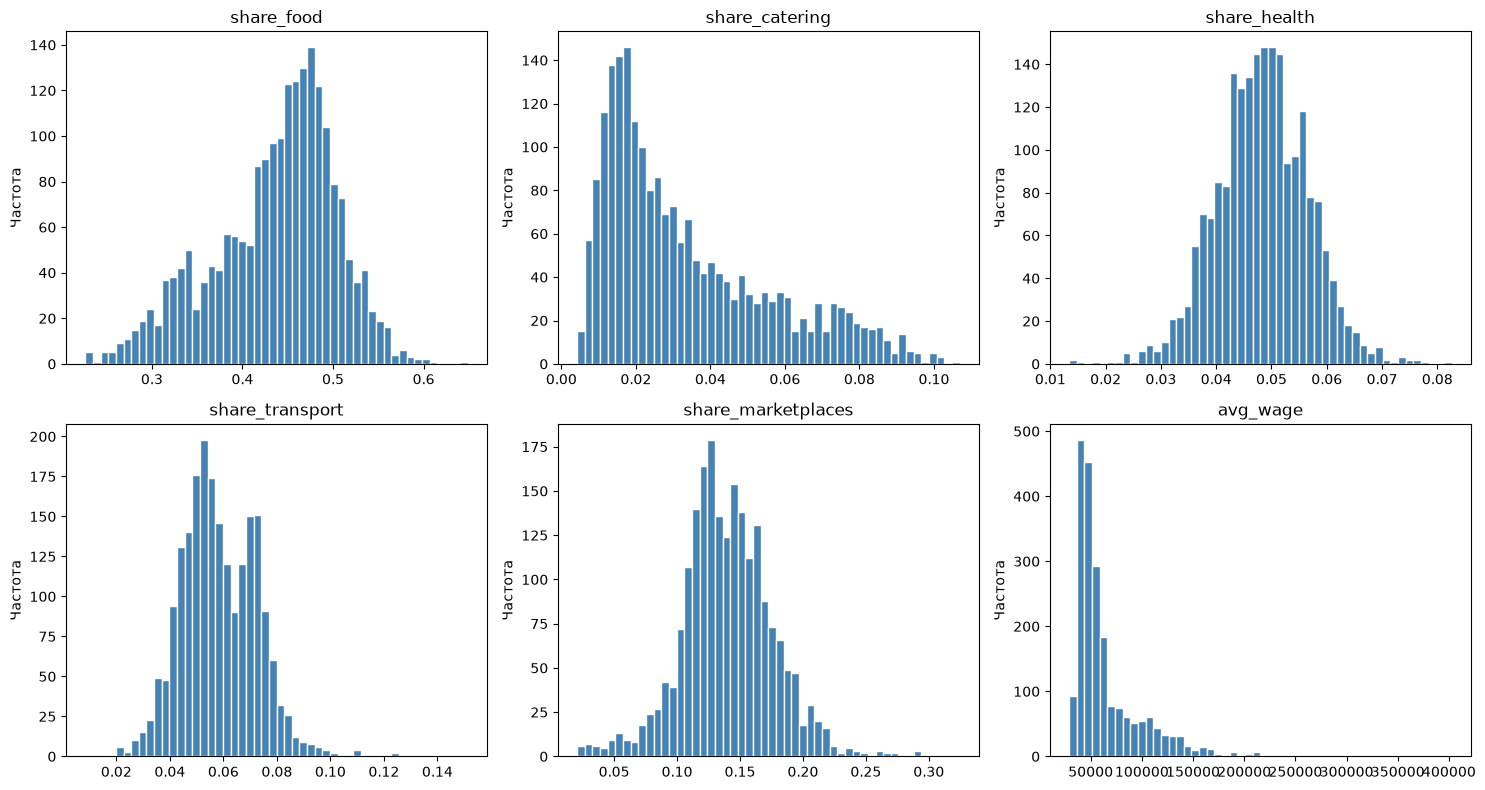

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features = ['share_food', 'share_catering', 'share_health', 
            'share_transport', 'share_marketplaces', 'avg_wage']

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

'share_food': нормальное распределение, немного смещенное вправо. Большинство МО тратит на еду 40–48% бюджета. Есть «хвост» бедных МО, где доля еды 55–65%. Экономический смысл: по мере роста дохода доля еды падает (закон Энгеля). МО с высокой долей еды — бедные.

share_catering: ассимметрия - только правая часть колокола, практически от начала координат. Большинство МО тратит на кафе/рестораны очень мало (0,5–2%). Есть «хвост» богатых МО, где доля 8–10%. Экономический смысл: кафе — это роскошь. Богатые города и туристические центры тратят больше.

'share_health': нормальное распределение, поджатое к центру. Доля трат на здоровье стабильна (4–5%) почти везде. Экономический смысл: здоровье — базовая потребность. Мало зависит от дохода.

'share_transport': похоже на колокол, но два пика посередине. Бимодальное распределение. Это значит, что есть два типа МО: одни тратят на транспорт мало, другие — много. Экономический смысл: возможно, городские (общественный транспорт, такси) vs сельские (личные авто). Или близкие к Москве (электрички) vs удалённые.

'share_marketplaces': похоже на колокол, но три пика посередине. Тримодальное. Есть три группы МО по использованию маркетплейсов. Экономический смысл: возможно, три уровня проникновения онлайн-торговли (крупные города → средние → удалённые, где Ozon/WB только недавно появились). Это очень интересный сигнал для кластеризации.
 
'avg_wage': ассимметрия - только правая часть колокола, практически от начала координат. → Большинство МО — с зарплатой 40–60к. Есть длинный хвост богатых (до 400к) — это северные вахтовые города. Экономический смысл: именно они — отдельный кластер.



Есть бедные МО (высокая доля еды).

Есть богатые (низкая доля еды, высокая доля кафе).

Есть северные вахтовые (зарплата 200–400к) — отдельная группа.

Есть город vs село (транспорт — два пика).

Есть три группы по маркетплейсам.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2108 entries, 0 to 2107
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mo_sber             2108 non-null   str    
 1   mo_rosstat          2108 non-null   str    
 2   oktmo_stable        2108 non-null   str    
 3   region_name         2108 non-null   str    
 4   score               2108 non-null   float64
 5   spend_total         2108 non-null   float64
 6   spend_health        2108 non-null   float64
 7   spend_marketplaces  2108 non-null   float64
 8   spend_catering      2108 non-null   float64
 9   spend_food          2108 non-null   float64
 10  spend_transport     2108 non-null   float64
 11  share_health        2108 non-null   float64
 12  share_marketplaces  2108 non-null   float64
 13  share_catering      2108 non-null   float64
 14  share_food          2108 non-null   float64
 15  share_transport     2108 non-null   float64
 16  log_total        

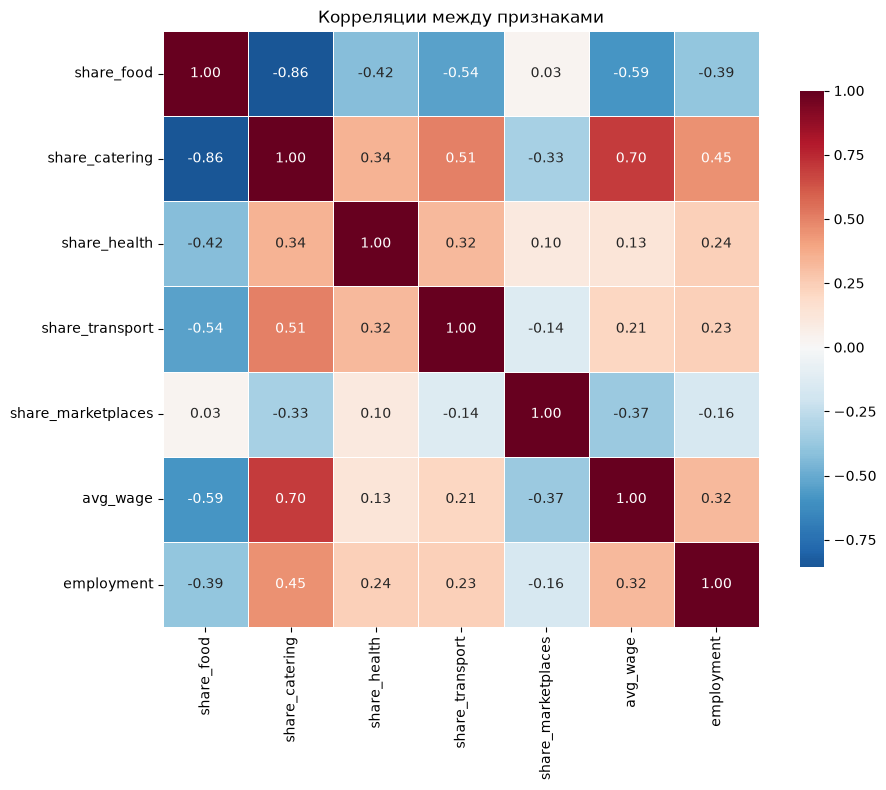

In [9]:
feature_cols = ['share_food', 'share_catering', 'share_health', 
                'share_transport', 'share_marketplaces', 'avg_wage', 'employment']

corr = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляции между признаками')
plt.tight_layout()
plt.show()

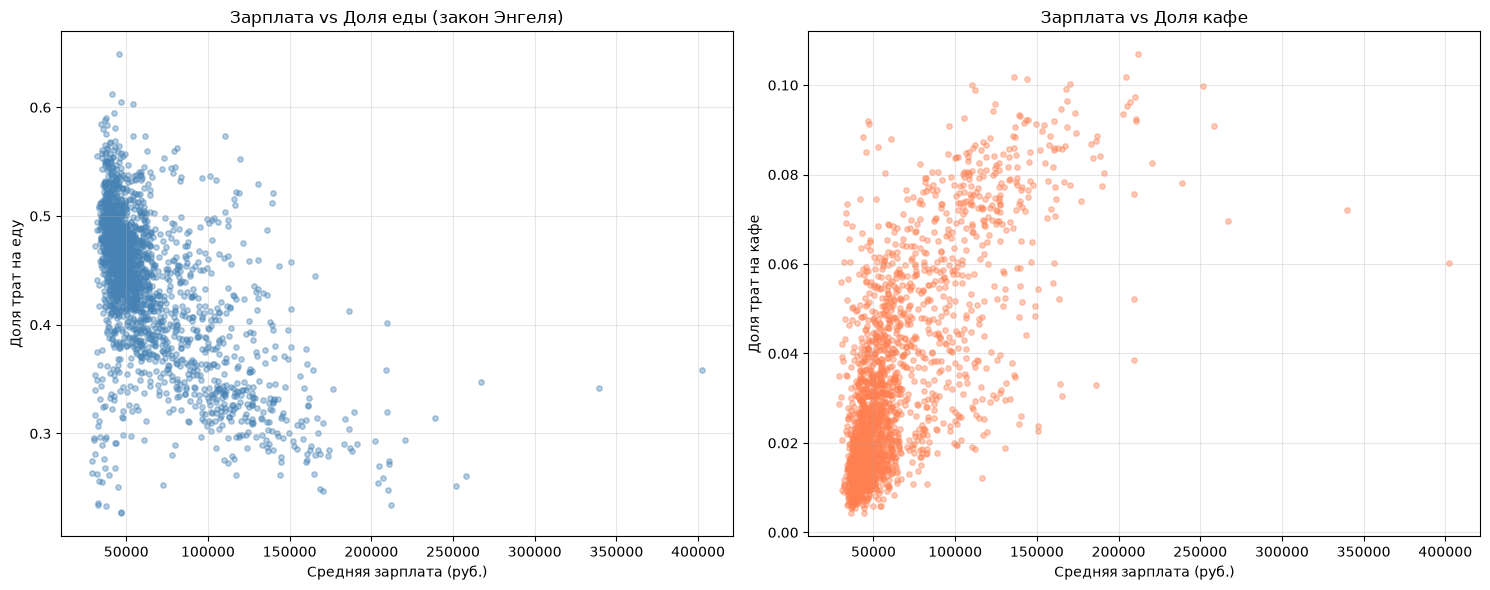

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: зарплата vs доля еды
axes[0].scatter(df['avg_wage'], df['share_food'], alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Средняя зарплата (руб.)')
axes[0].set_ylabel('Доля трат на еду')
axes[0].set_title('Зарплата vs Доля еды (закон Энгеля)')
axes[0].grid(alpha=0.3)

# Scatter: зарплата vs доля кафе (в логарифме по X)
axes[1].scatter(df['avg_wage'], df['share_catering'], alpha=0.4, s=15, color='coral')
axes[1].set_xlabel('Средняя зарплата (руб.)')
axes[1].set_ylabel('Доля трат на кафе')
axes[1].set_title('Зарплата vs Доля кафе')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Закон Энгеля подтверждён. Это классический результат: с ростом дохода доля еды падает. Здесь видно идеально.

2. Есть «ядро» и «периферия».

80% МО — плотное ядро с зарплатой 40–80к и долей еды 40–50%.

Хвост справа — аномалия (северные города).

Хвост слева — бедные МО с зарплатой 30–40к.

3. Северные города — отдельный тип.
На правом графике видно: они выпадают из общей зависимости. Это будущий отдельный кластер.

4. Разброс уменьшается с ростом зарплаты.
У бедных МО большой разброс по доле еды (0.25–0.65). У богатых — узкий (0.25–0.35). Это нормально — у богатых потребительские паттерны более однородны.

Мы уже можем предсказать структуру кластеров:

Кластер 1: «бедные» — низкая зарплата, высокая доля еды.

Кластер 2: «средние» — средняя зарплата, средняя доля еды (ядро).

Кластер 3: «богатые» — высокая зарплата, низкая доля еды, много кафе.

Кластер 4: «северные вахтовые» — очень высокая зарплата, но низкая доля кафе (аномалия).

Возможно, будет 5-й кластер — по share_marketplaces или share_transport.

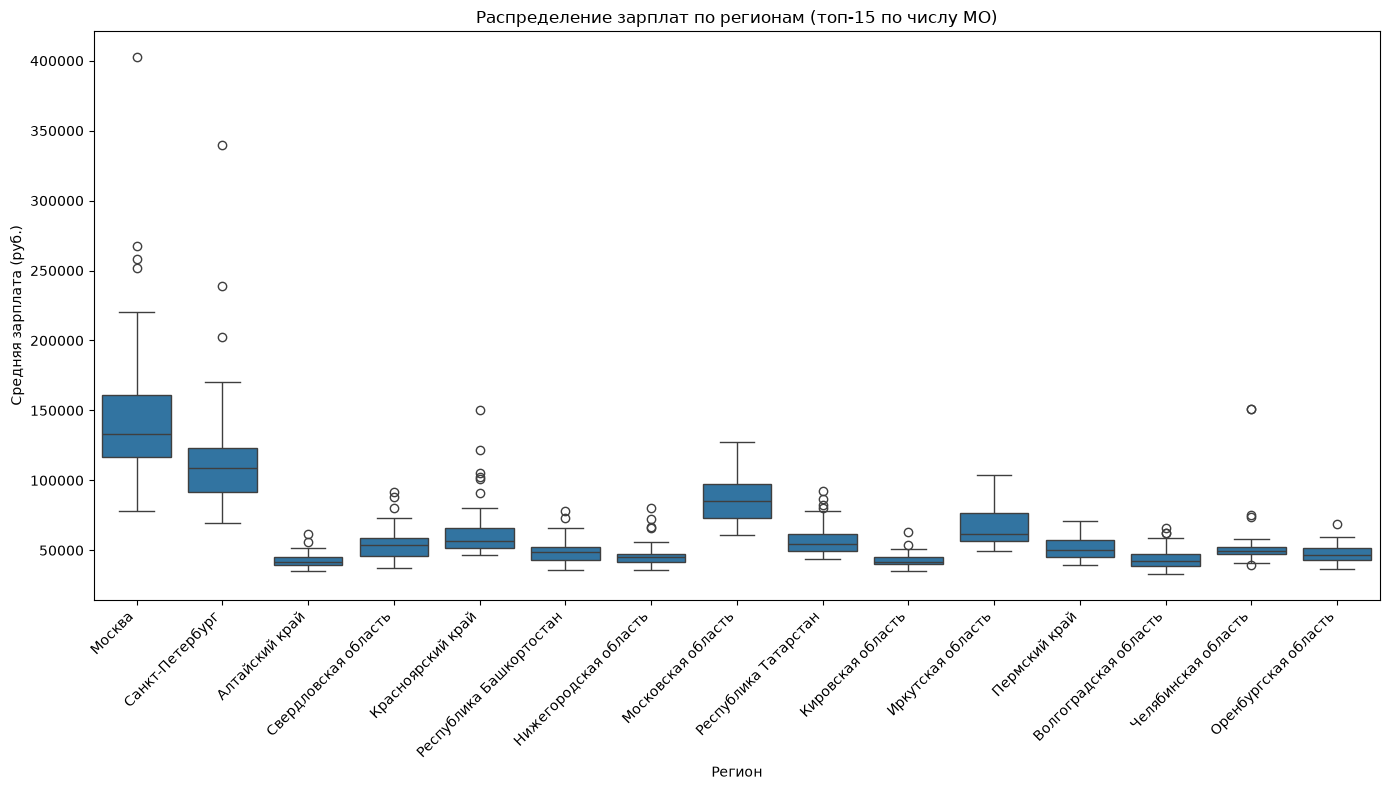

In [11]:
# Топ-15 регионов по количеству МО
top_regions = df['region_name'].value_counts().head(15).index

# Фильтруем данные
df_top = df[df['region_name'].isin(top_regions)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top, x='region_name', y='avg_wage', order=top_regions)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Регион')
plt.ylabel('Средняя зарплата (руб.)')
plt.title('Распределение зарплат по регионам (топ-15 по числу МО)')
plt.tight_layout()
plt.show()

1. Москва — отдельный мир.
Её медиана выше большинства регионов в 3 раза. Это не «регион-лидер», это отдельная экономика.

2. Внутрирегиональное неравенство.
Даже в благополучных регионах есть бедные МО. Регион — не главный фактор. Важнее тип МО внутри региона.

3. Выбросы — это конкретные типы МО.

Северные вахтовые (Норильск, Мурманск).

ЗАТО.

Наукограды.

4. Большинство регионов — «серая масса».
Их медианы близки. Значит, кластеризация должна идти внутри регионов, а не по регионам.

Что это значит для нашей задачи
Кластеризация по «регион» — не сработает. Большинство регионов одинаковы.

Кластеризация по «тип МО внутри региона» — сработает. Потому что именно внутри регионов скрыто разнообразие.

Это подтверждает нашу гипотезу: нужно строить экономическую сеть по схожести МО, а не группировать по географии.

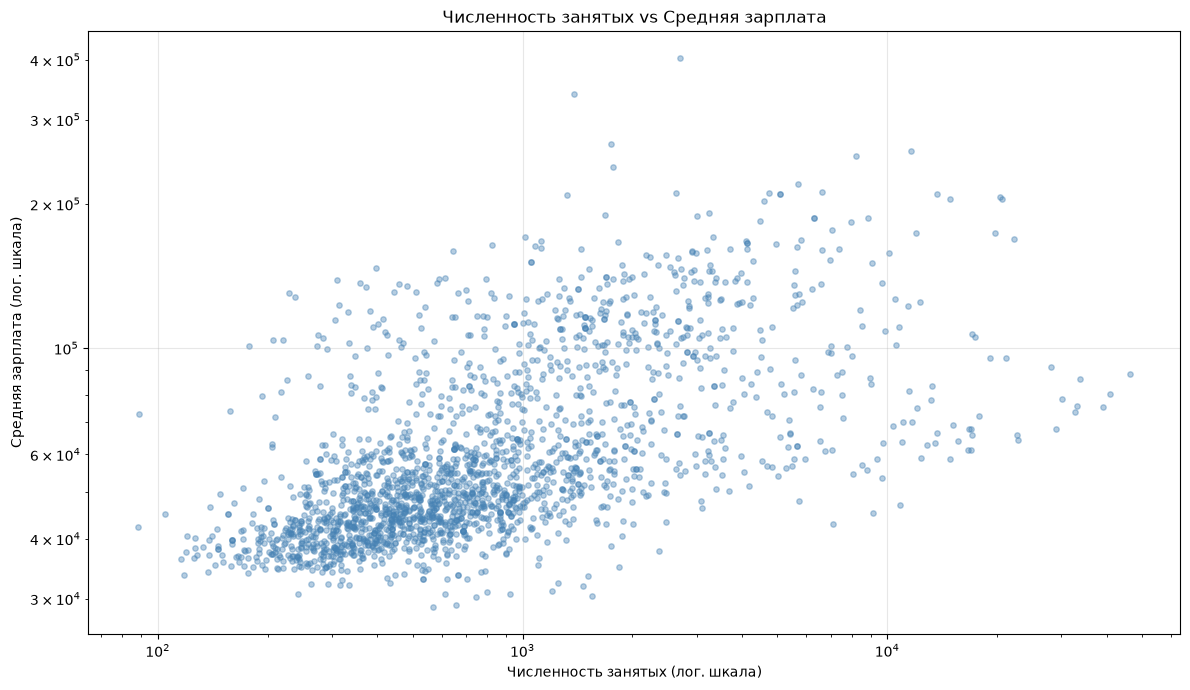

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

# Основной scatter
ax.scatter(df['employment'], df['avg_wage'], alpha=0.4, s=15, color='steelblue')

# Логарифмическая шкала по обеим осям (разброс огромный)
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Численность занятых (лог. шкала)')
ax.set_ylabel('Средняя зарплата (лог. шкала)')
ax.set_title('Численность занятых vs Средняя зарплата')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Размер города ≠ богатство.
Есть мелкие богатые (вахтовые) и крупные бедные (депрессивные). Связь слабая.

2. Три чётких «полюса»:

Ядро — обычные МО (80%).

Богатые вахтовые — маленькие, очень богатые (аномалия сверху).

Богатые агломерации — крупные, богатые (верхний правый угол).

3. «Депрессивные крупные» — крупные, но бедные (нижний правый угол). Их немного, но они важны.

4. Всё это — кандидаты в кластеры.

Кластер «обычные МО».

Кластер «северные вахтовые».

Кластер «крупные агломерации».

Кластер «депрессивные крупные».



In [13]:
# Топ-10 и боттом-10 по зарплате
top_wage = df.nlargest(10, 'avg_wage')[['mo_sber', 'region_name', 'avg_wage', 'employment']]
bottom_wage = df.nsmallest(10, 'avg_wage')[['mo_sber', 'region_name', 'avg_wage', 'employment']]

print('=== ТОП-10 МО ПО ЗАРПЛАТЕ ===')
print(top_wage.to_string(index=False))
print()
print('=== БОТТОМ-10 МО ПО ЗАРПЛАТЕ ===')
print(bottom_wage.to_string(index=False))

=== ТОП-10 МО ПО ЗАРПЛАТЕ ===
                                                                                         mo_sber     region_name      avg_wage   employment
             внутригородская территория города федерального значения муниципальный округ Внуково          Москва 402558.973077  2705.750000
          внутригородская территория города федерального значения муниципальный округ Балканский Санкт-Петербург 339652.904545  1384.000000
           внутригородская территория города федерального значения муниципальный округ Зябликово          Москва 267305.729412  1750.000000
         внутригородская территория города федерального значения муниципальный округ Хорошевский          Москва 258128.505556 11626.970588
            внутригородская территория города федерального значения муниципальный округ Якиманка          Москва 251609.550000  8187.921053
       внутригородская территория города федерального значения муниципальный округ Лахта-Ольгино Санкт-Петербург 238733.162963  17

In [14]:
# Ищем конкретные северные города
cities_to_find = ['Норильск', 'Новый Уренгой', 'Салехард', 'Ноябрьск', 
                  'Магадан', 'Анадырь', 'Воркута', 'Сургут', 'Нижневартовск',
                  'Мурманск', 'Якутск']

print('СЕВЕРНЫЕ ГОРОДА В ДАННЫХ:')
print('=' * 100)
for city in cities_to_find:
    mask = df['mo_sber'].str.contains(city, case=False, na=False)
    if mask.any():
        row = df[mask].iloc[0]
        print(f'{city:<20} | {row["region_name"]:<30} | зарплата: {row["avg_wage"]:>10.0f} | занятость: {row["employment"]:>8.0f}')
    else:
        print(f'{city:<20} | НЕ НАЙДЕН')

СЕВЕРНЫЕ ГОРОДА В ДАННЫХ:
Норильск             | Красноярский край              | зарплата:     150646 | занятость:     9055
Новый Уренгой        | Ямало-Ненецкий автономный округ | зарплата:     161355 | занятость:     7386
Салехард             | Ямало-Ненецкий автономный округ | зарплата:     149013 | занятость:     2347
Ноябрьск             | Ямало-Ненецкий автономный округ | зарплата:     129860 | занятость:     3224
Магадан              | Магаданская область            | зарплата:     139973 | занятость:     3390
Анадырь              | Чукотский автономный округ     | зарплата:     163391 | занятость:     1083
Воркута              | Республика Коми                | зарплата:     106737 | занятость:     2471
Сургут               | Ханты-Мансийский автономный округ — Югра | зарплата:     108524 | занятость:     9882
Нижневартовск        | Ханты-Мансийский автономный округ — Югра | зарплата:      90501 | занятость:     4779
Мурманск             | Мурманская область             | зарп

Мы имеем три «полюса богатства»:

Группа	Зарплата	Примеры
Мегаполисы (Москва, СПб)	200–400к	Внуково, Балканский, Якиманка
Северные вахтовые	90–165к	Анадырь, Новый Уренгой, Норильск
Обычные МО	30–70к	Большинство
Это три разных экономических типа. Кластеризация должна их разделить.

Проблема: Москва и СПб — это не отдельные МО, а части городов. Если оставить их в анализе, они «сломают» кластер «богатые», потому что там будут рядом и северные города (160к), и московские округа (400к) — это разные вещи.

In [15]:
# Признак "мегаполис" — внутригородские территории Москвы и СПб
df['is_metropolitan'] = df['mo_sber'].str.contains(
    'внутригородская территория', case=False, na=False
)

# Признак "северный" — по региону
northern_regions = [
    'Ямало-Ненецкий автономный округ',
    'Ханты-Мансийский автономный округ',
    'Чукотский автономный округ',
    'Магаданская область',
    'Мурманская область',
    'Республика Коми',
    'Республика Саха (Якутия)',
    'Красноярский край',  # Норильск
    'Камчатский край',
    'Архангельская область',
]
df['is_northern'] = df['region_name'].isin(northern_regions)

print('Мегаполисных МО (Москва + СПб):', df['is_metropolitan'].sum())
print('Северных МО:', df['is_northern'].sum())
print()
print('Северные МО по регионам:')
print(df[df['is_northern']].groupby('region_name').size().sort_values(ascending=False))

Мегаполисных МО (Москва + СПб): 246
Северных МО: 184

Северные МО по регионам:
region_name
Красноярский край                  62
Республика Саха (Якутия)           34
Республика Коми                    20
Архангельская область              18
Мурманская область                 12
Ямало-Ненецкий автономный округ    12
Камчатский край                    11
Магаданская область                 9
Чукотский автономный округ          6
dtype: int64


In [18]:
df['is_northern'] = df['avg_wage'] > 90000

In [19]:
# Признак "мегаполис" — внутригородские территории Москвы и СПб
df['is_metropolitan'] = df['mo_sber'].str.contains(
    'внутригородская территория', case=False, na=False
)

print('Мегаполисных МО (Москва + СПб):', df['is_metropolitan'].sum())
print()
print('Из них:')
print(df[df['is_metropolitan']].groupby('region_name').size())
print()
print('Средняя зарплата:')
print('  Мегаполисы:', df[df['is_metropolitan']]['avg_wage'].mean().round(0))
print('  Остальные:', df[~df['is_metropolitan']]['avg_wage'].mean().round(0))

Мегаполисных МО (Москва + СПб): 246

Из них:
region_name
Амурская область           1
Белгородская область       1
Волгоградская область      1
Вологодская область        1
Костромская область        1
Ленинградская область      1
Москва                   140
Нижегородская область      1
Санкт-Петербург           98
Ставропольский край        1
dtype: int64

Средняя зарплата:
  Мегаполисы: 128266.0
  Остальные: 56342.0


In [20]:
# Признак "мегаполис" — только внутригородские территории Москвы и СПб
df['is_metropolitan'] = (
    df['mo_sber'].str.contains('внутригородская территория', case=False, na=False)
    & df['region_name'].isin(['Москва', 'Санкт-Петербург'])
)

print('Мегаполисных МО (только Москва + СПб):', df['is_metropolitan'].sum())
print()
print('По регионам:')
print(df[df['is_metropolitan']].groupby('region_name').size())
print()
print('Средняя зарплата:')
print('  Мегаполисы (Мск + СПб):', df[df['is_metropolitan']]['avg_wage'].mean().round(0))
print('  Остальные:            ', df[~df['is_metropolitan']]['avg_wage'].mean().round(0))
print()
print('Проверим: какие 8 МО были "ложными мегаполисами":')
false_metro = df[
    df['mo_sber'].str.contains('внутригородская территория', case=False, na=False)
    & ~df['region_name'].isin(['Москва', 'Санкт-Петербург'])
]
print(false_metro[['mo_sber', 'region_name', 'avg_wage']].to_string(index=False))

Мегаполисных МО (только Москва + СПб): 238

По регионам:
region_name
Москва             140
Санкт-Петербург     98
dtype: int64

Средняя зарплата:
  Мегаполисы (Мск + СПб): 130757.0
  Остальные:             56332.0

Проверим: какие 8 МО были "ложными мегаполисами":
                                                                                     mo_sber           region_name     avg_wage
внутригородская территория города федерального значения  Александровский муниципальный округ   Ставропольский край 41517.010345
    внутригородская территория города федерального значения муниципальный округ Алексеевский  Белгородская область 60963.022222
    внутригородская территория города федерального значения муниципальный округ Бабушкинский   Вологодская область 51617.014286
     внутригородская территория города федерального значения муниципальный округ Даниловский Волгоградская область 43561.540625
      внутригородская территория города федерального значения муниципальный округ Ивановский  

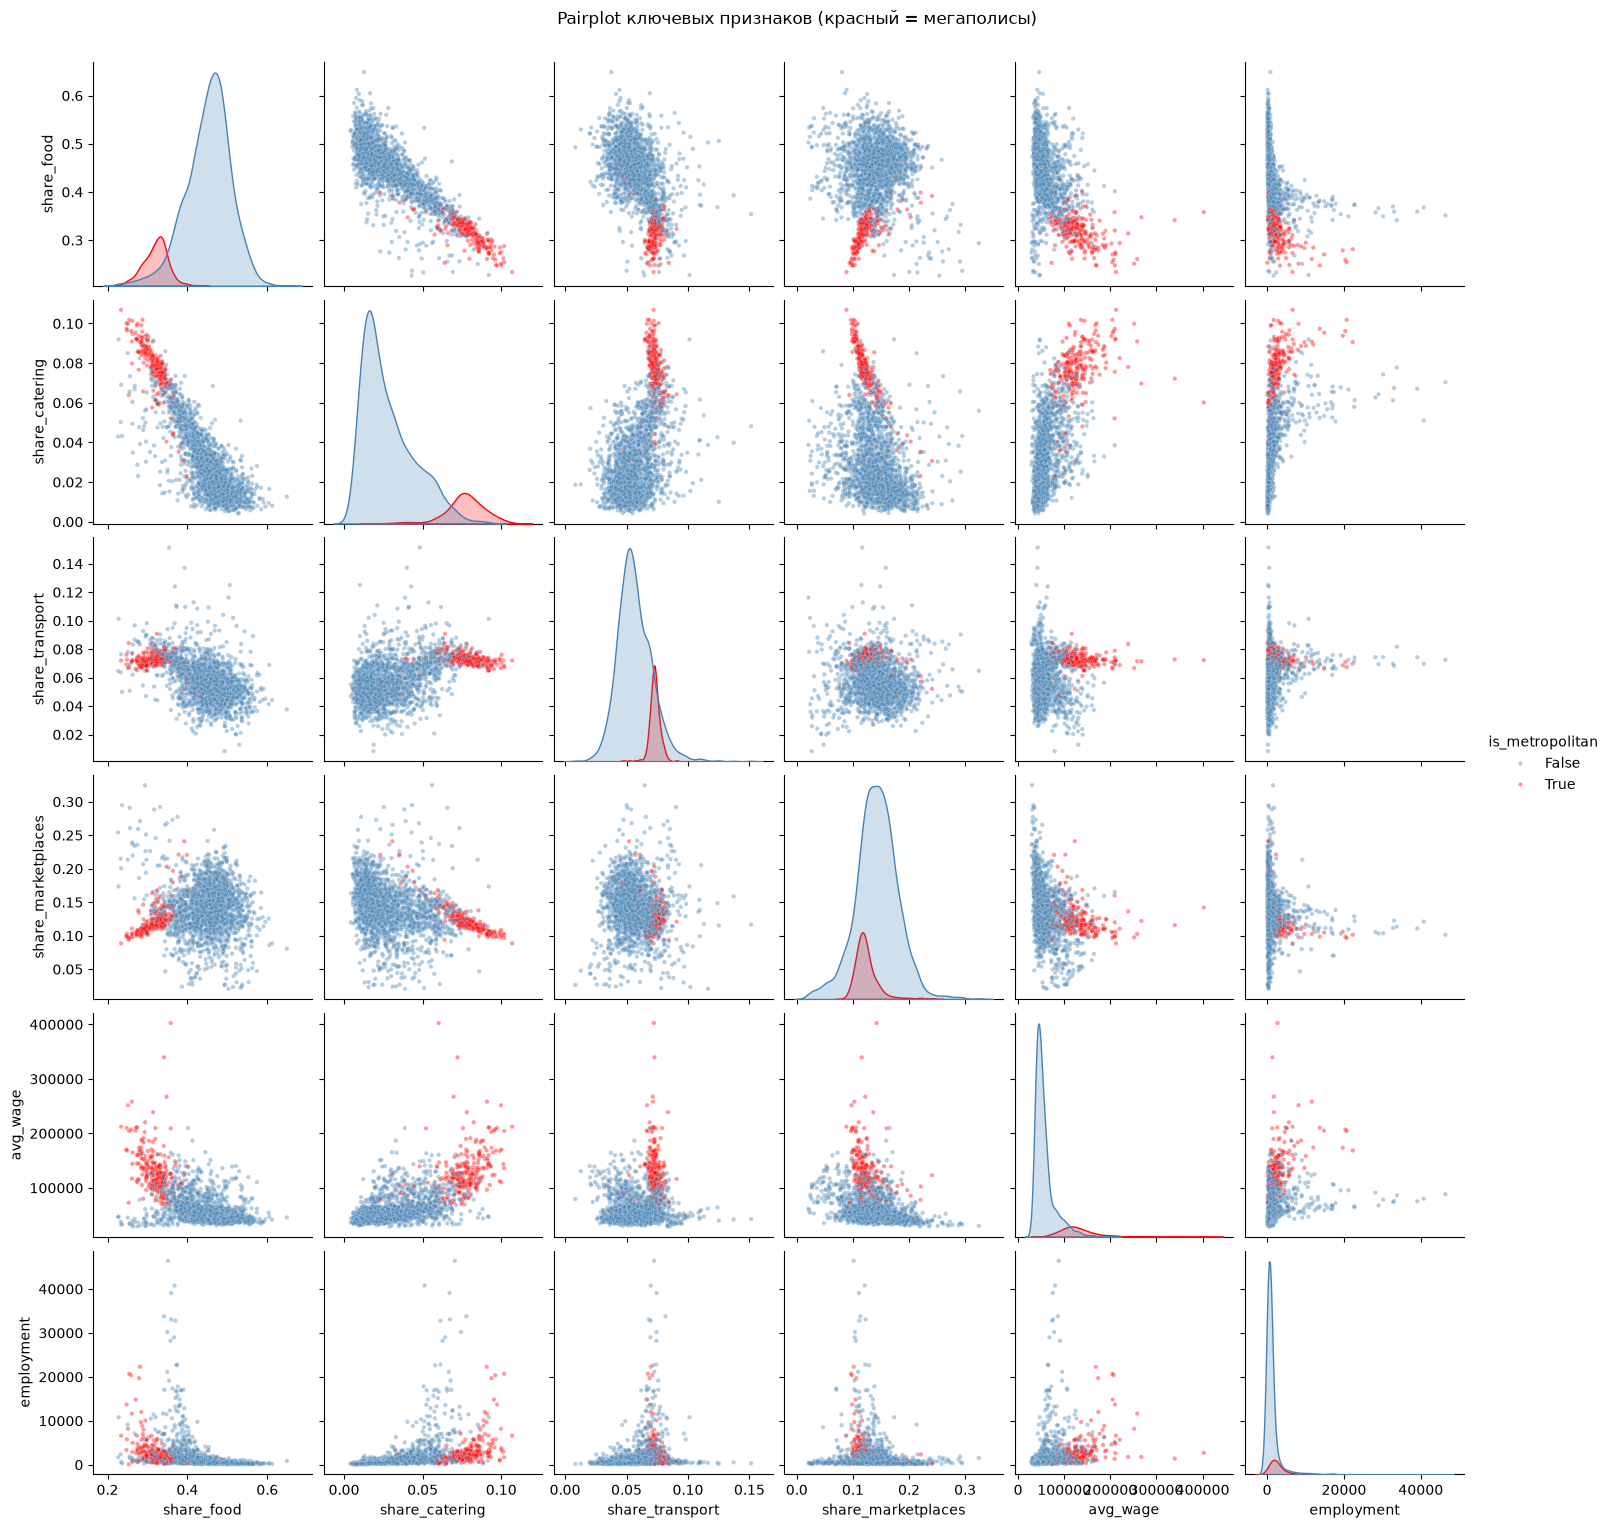

In [21]:
# Ключевые признаки для парного анализа
pair_features = ['share_food', 'share_catering', 'share_transport', 
                 'share_marketplaces', 'avg_wage', 'employment']

# Строим pairplot, раскрашиваем по is_metropolitan
g = sns.pairplot(
    df, 
    vars=pair_features,
    hue='is_metropolitan',
    palette={True: 'red', False: 'steelblue'},
    plot_kws={'alpha': 0.4, 's': 10},
    diag_kind='kde',
    height=2.5
)
g.fig.suptitle('Pairplot ключевых признаков (красный = мегаполисы)', y=1.02)
plt.show()

1. Мегаполисы — отдельная группа.
Красные точки везде отделены от синих. Это не «крайние значения», а другой тип экономики.

2. share_food — самый «разделяющий» признак.
Он лучше всего отделяет мегаполисы от остальных.

3. share_marketplaces — «самостоятельный».
Не связан ни с зарплатой, ни с долей еды. Возможно, это отдельное измерение — уровень цифровизации.

4. Остальные признаки (синие) — плотное облако.
Они не разделяются на явные группы в 2D. Значит, для кластеризации нужны все признаки вместе — в многомерном пространстве.

Сохранено: results/eda/pairplot.png
Сохранено: results/eda/histograms.png
Сохранено: results/eda/correlations.png
Сохранено: results/eda/engel_law.png

Все графики сохранены в results/eda/


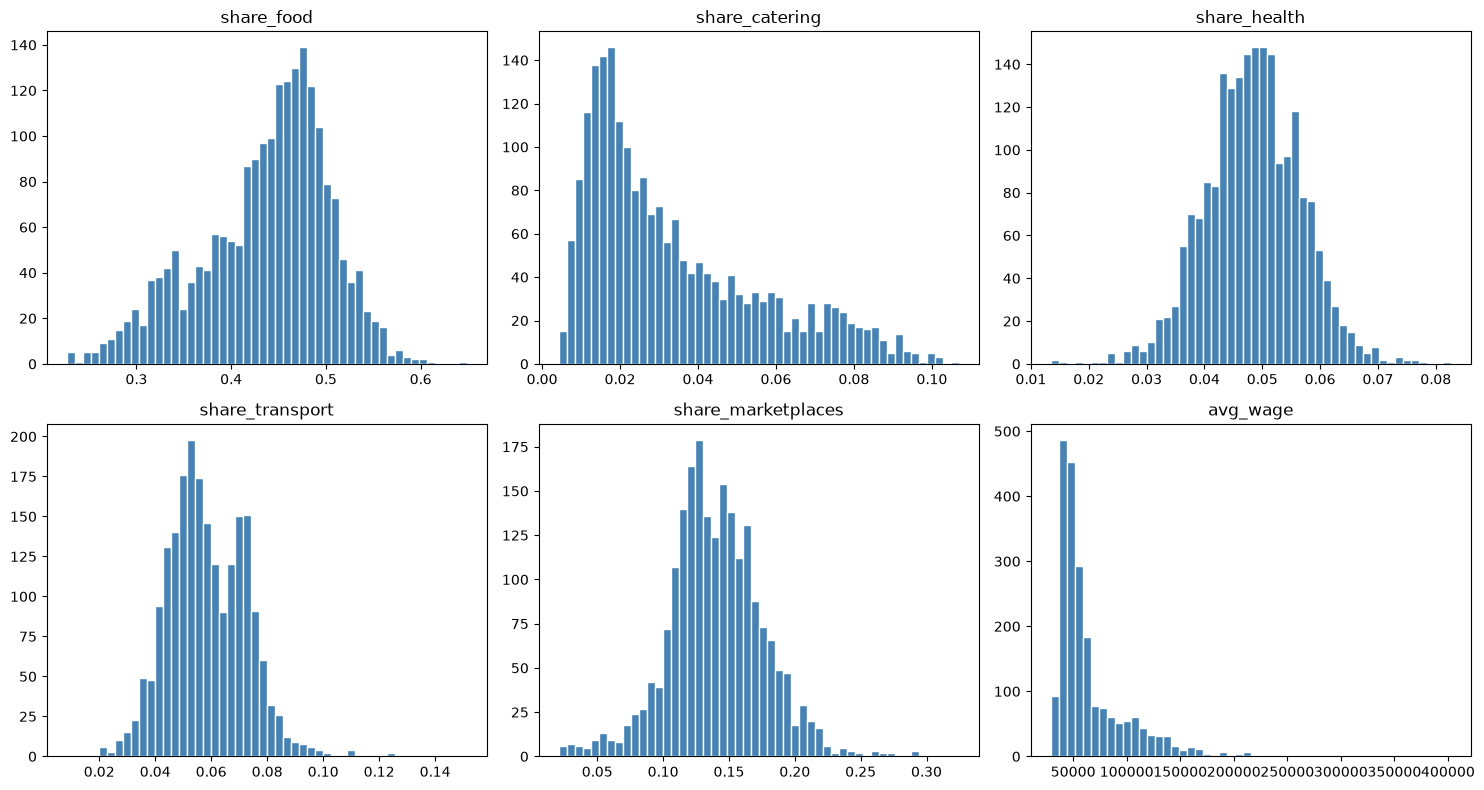

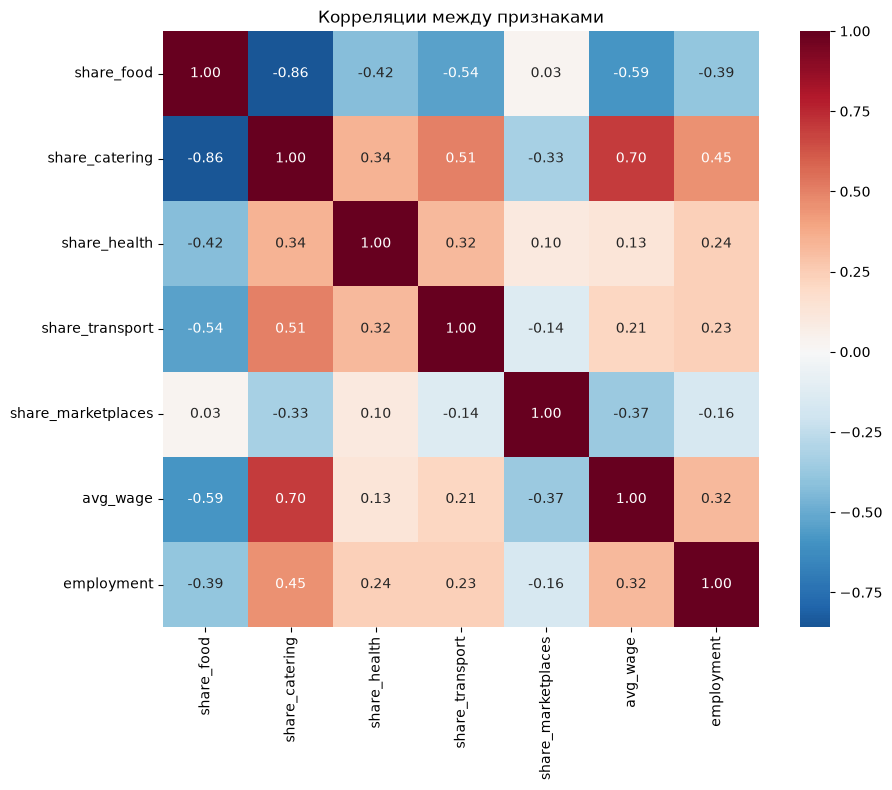

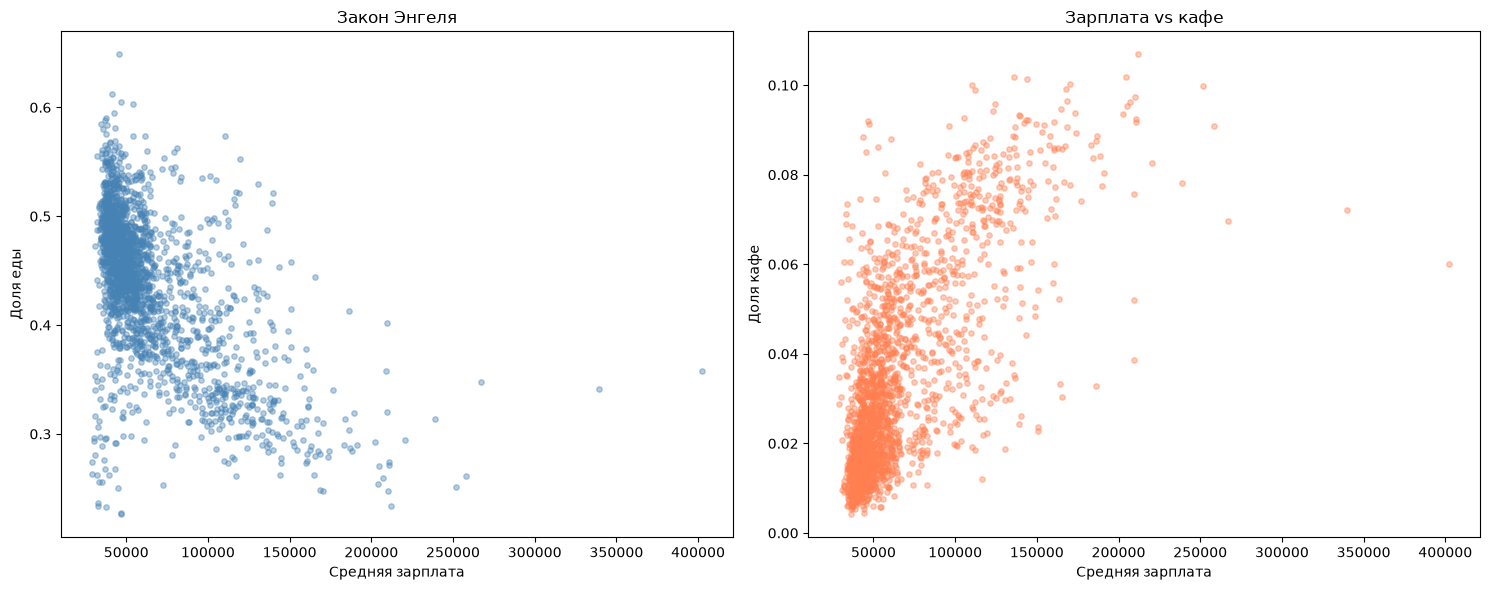

In [22]:
import os
from pathlib import Path

# Создаём папку для графиков
Path('results/eda').mkdir(parents=True, exist_ok=True)

# Сохраняем pairplot
g.savefig('results/eda/pairplot.png', dpi=100, bbox_inches='tight')
print('Сохранено: results/eda/pairplot.png')

# Сохраняем все остальные графики, которые строили ранее
# (нужно перезапустить те ячейки — но проще сохранить заново)

# 1. Гистограммы
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
features = ['share_food', 'share_catering', 'share_health', 
            'share_transport', 'share_marketplaces', 'avg_wage']
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(feat)
plt.tight_layout()
plt.savefig('results/eda/histograms.png', dpi=100, bbox_inches='tight')
print('Сохранено: results/eda/histograms.png')

# 2. Корреляции
feature_cols = ['share_food', 'share_catering', 'share_health', 
                'share_transport', 'share_marketplaces', 'avg_wage', 'employment']
corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Корреляции между признаками')
plt.tight_layout()
plt.savefig('results/eda/correlations.png', dpi=100, bbox_inches='tight')
print('Сохранено: results/eda/correlations.png')

# 3. Scatter: закон Энгеля
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(df['avg_wage'], df['share_food'], alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Средняя зарплата')
axes[0].set_ylabel('Доля еды')
axes[0].set_title('Закон Энгеля')
axes[1].scatter(df['avg_wage'], df['share_catering'], alpha=0.4, s=15, color='coral')
axes[1].set_xlabel('Средняя зарплата')
axes[1].set_ylabel('Доля кафе')
axes[1].set_title('Зарплата vs кафе')
plt.tight_layout()
plt.savefig('results/eda/engel_law.png', dpi=100, bbox_inches='tight')
print('Сохранено: results/eda/engel_law.png')

print()
print('Все графики сохранены в results/eda/')

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ключевые признаки для кластеризации
cluster_features = ['share_food', 'share_catering', 'share_health', 
                    'share_transport', 'share_marketplaces', 
                    'avg_wage', 'employment']

# Стандартизируем
X = df[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X)

# Считаем VIF
vif_data = pd.DataFrame()
vif_data['feature'] = cluster_features
vif_data['VIF'] = [
    variance_inflation_factor(X_scaled, i) 
    for i in range(X_scaled.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)

print('VIF (Variance Inflation Factor):')
print('=' * 40)
print(vif_data.to_string(index=False))
print()
print('Интерпретация:')
print('  VIF < 5   — хорошо')
print('  VIF 5–10  — умеренная мультиколлинеарность')
print('  VIF > 10  — сильная, надо что-то убрать')

VIF (Variance Inflation Factor):
           feature      VIF
    share_catering 6.582810
        share_food 5.827343
          avg_wage 2.211368
share_marketplaces 1.662805
   share_transport 1.572972
      share_health 1.292695
        employment 1.270403

Интерпретация:
  VIF < 5   — хорошо
  VIF 5–10  — умеренная мультиколлинеарность
  VIF > 10  — сильная, надо что-то убрать


Проверка VIF показала, что максимальный VIF = 6.58 (share_catering), что ниже порога 10. Сильной мультиколлинеарности нет, все признаки оставлены

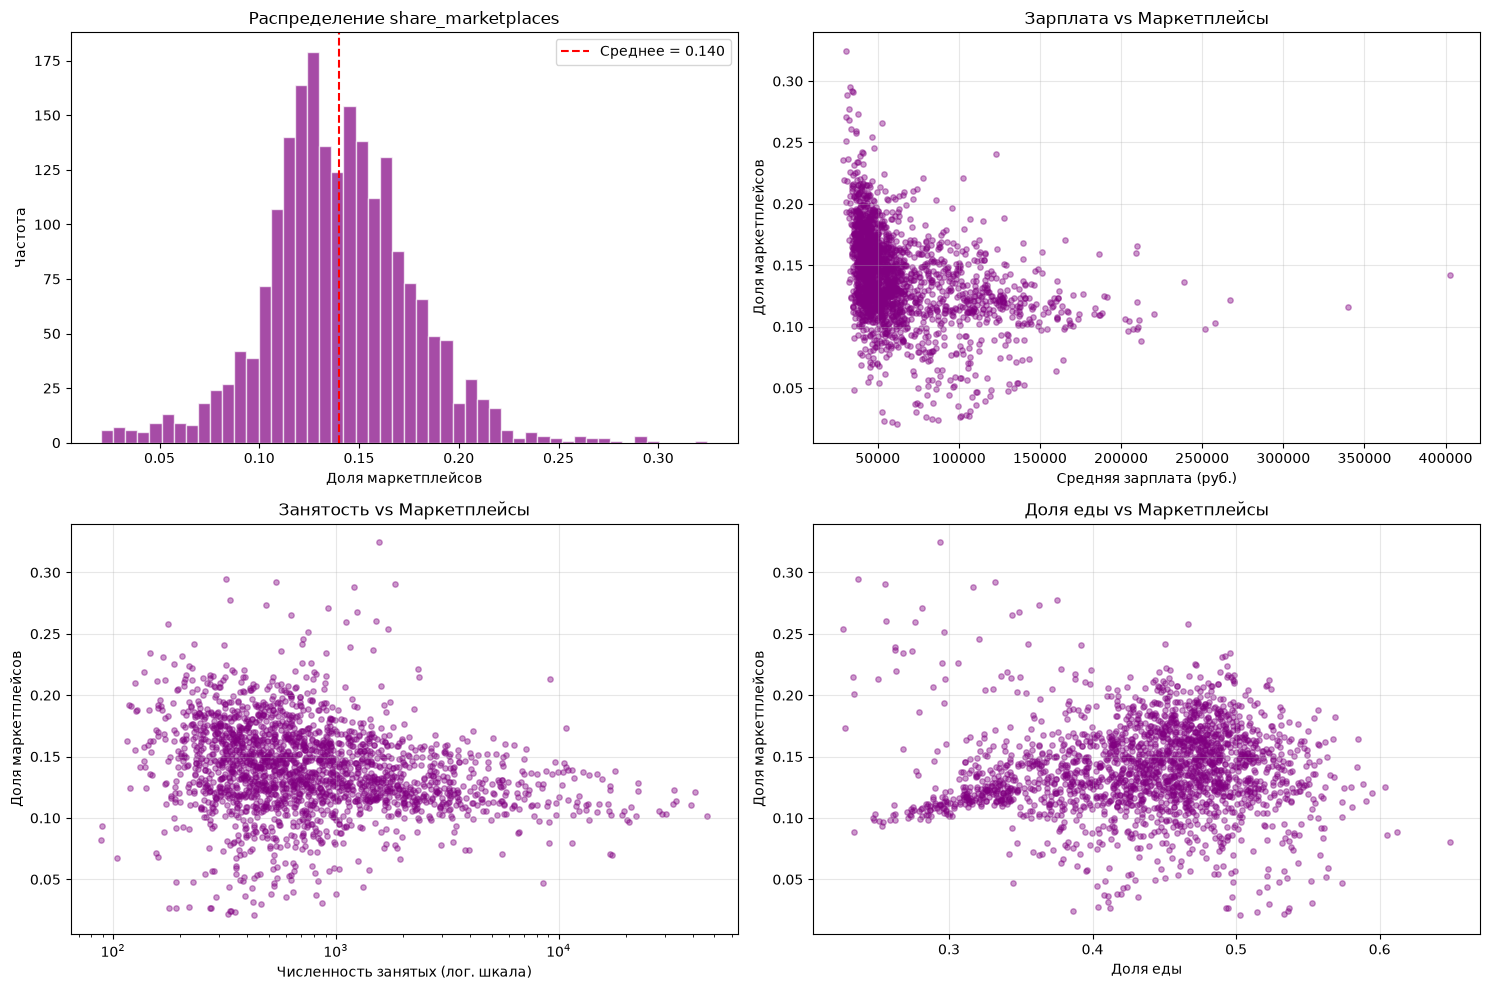

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение share_marketplaces
axes[0, 0].hist(df['share_marketplaces'], bins=50, color='purple', edgecolor='white', alpha=0.7)
axes[0, 0].set_xlabel('Доля маркетплейсов')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title(f'Распределение share_marketplaces')
axes[0, 0].axvline(df['share_marketplaces'].mean(), color='red', linestyle='--', label=f'Среднее = {df["share_marketplaces"].mean():.3f}')
axes[0, 0].legend()

# 2. Связь с зарплатой
axes[0, 1].scatter(df['avg_wage'], df['share_marketplaces'], alpha=0.4, s=15, color='purple')
axes[0, 1].set_xlabel('Средняя зарплата (руб.)')
axes[0, 1].set_ylabel('Доля маркетплейсов')
axes[0, 1].set_title('Зарплата vs Маркетплейсы')
axes[0, 1].grid(alpha=0.3)

# 3. Связь с занятостью (лог. шкала)
axes[1, 0].scatter(df['employment'], df['share_marketplaces'], alpha=0.4, s=15, color='purple')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Численность занятых (лог. шкала)')
axes[1, 0].set_ylabel('Доля маркетплейсов')
axes[1, 0].set_title('Занятость vs Маркетплейсы')
axes[1, 0].grid(alpha=0.3)

# 4. Связь с долей еды
axes[1, 1].scatter(df['share_food'], df['share_marketplaces'], alpha=0.4, s=15, color='purple')
axes[1, 1].set_xlabel('Доля еды')
axes[1, 1].set_ylabel('Доля маркетплейсов')
axes[1, 1].set_title('Доля еды vs Маркетплейсы')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/eda/marketplaces_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

Вывод: share_marketplaces — нормально распределённый признак. Никаких «скрытых групп

Зарплата vs маркетплейсы (верхний правый)
Слабая обратная связь! Смотри: при зарплате 50к — разброс маркетплейсов от 0.03 до 0.30. При зарплате 200к — все точки в узком диапазоне 0.10–0.15.

Богатые МО (200к+) — средняя доля маркетплейсов (0.10–0.15).

Бедные МО (30–50к) — огромный разброс: от 0.02 до 0.30.

Вывод: в богатых МО доля маркетплейсов стабильна. В бедных — хаос: есть МО с высокой долей (0.25–0.30) и есть с низкой (0.03). Это важно

3. Занятость vs маркетплейсы (нижний левый)
Слабая связь.

Крупные МО (10 000+) — маркетплейсы 0.10–0.15.

Мелкие (100–1000) — широкий разброс 0.02–0.30.

Вывод: размер города не определяет долю маркетплейсов.

Доля еды vs маркетплейсы (нижний правый)
Лёгкая положительная связь: чем выше доля еды, тем выше маркетплейсы.

При доле еды 0.30 — маркетплейсы 0.10–0.13.

При доле еды 0.50 — маркетплейсы 0.12–0.20.

Вывод: в «бедных» МО (высокая доля еды) маркетплейсы играют большую роль. Возможно, потому что в бедных регионах меньше офлайн-магазинов и люди заказывают онлайн.

Итоговый вывод по share_marketplaces
1. Не связан с богатством напрямую.
Связь слабая. Богатые — средние. Бедные — разнообразные.

2. В бедных МО — «хаос».
Есть бедные МО с очень высокой долей маркетплейсов (0.30). Есть бедные с очень низкой (0.03).

3. Гипотеза: маркетплейсы — «заменитель» офлайн-инфраструктуры.
Где мало магазинов (удалённые, малые МО) — люди заказывают онлайн. Где магазины есть — покупают в них.

Отдельный кластер «цифровые МО» возможен.
МО с долей маркетплейсов 0.20+ могут выделиться в кластер.





In [26]:
# Топ-10 и боттом-10 по маркетплейсам
top_mp = df.nlargest(10, 'share_marketplaces')[['mo_sber', 'region_name', 'share_marketplaces', 'avg_wage', 'employment']]
bottom_mp = df.nsmallest(10, 'share_marketplaces')[['mo_sber', 'region_name', 'share_marketplaces', 'avg_wage', 'employment']]

print('=== ТОП-10 МО ПО ДОЛЕ МАРКЕТПЛЕЙСОВ ===')
print(top_mp.to_string(index=False))
print()
print('=== БОТТОМ-10 МО ПО ДОЛЕ МАРКЕТПЛЕЙСОВ ===')
print(bottom_mp.to_string(index=False))

=== ТОП-10 МО ПО ДОЛЕ МАРКЕТПЛЕЙСОВ ===
                                mo_sber                     region_name  share_marketplaces     avg_wage  employment
  Урус-Мартановский муниципальный район            Чеченская Республика            0.324503 30302.692593 1555.038462
   городской округ город Южно-Сухокумск             Республика Дагестан            0.294824 32741.622727  320.066667
         Лескенский муниципальный район Кабардино-Балкарская Республика            0.292092 34221.470588  540.600000
       Гудермесский муниципальный район            Чеченская Республика            0.290921 34871.463636 1841.838710
      Бабаюртовский муниципальный район             Республика Дагестан            0.288491 31075.094737 1208.230769
        Яшалтинский муниципальный район             Республика Калмыкия            0.277305 32021.466667  333.923077
           Урупский муниципальный район Карачаево-Черкесская Республика            0.273059 38087.457143  487.857143
городской округ город Да

Гипотеза «удалённость → маркетплейсы» — НЕ подтвердилась.

Оба региона удалённые, но:

Северный Кавказ — высокая доля маркетплейсов.

Якутия/Забайкалье — низкая доля маркетплейсов.

Значит, дело не в удалённости.

Реальная гипотеза: плотность населения и логистика
Северный Кавказ:

Высокая плотность населения.

Развитая логистика — маркетплейсы легко доставляют.

Много пунктов выдачи (ПВЗ).

Молодое население — активно заказывает онлайн.

Малый офлайн-ритейл — мало крупных магазинов, поэтому онлайн выручает.

Якутия/Забайкалье:

Крайне низкая плотность — на 1000 км² может быть 1 посёлок.

Логистика дорогая — доставка в Абыйский район стоит как сам товар.

Мало ПВЗ — только в крупных центрах.

Оленеводы, вахтовики — не заказывают онлайн.

Зарплаты высокие (северные надбавки), но покупать негде.

Вывод: share_marketplaces — это не «богатство» и не «удалённость», а сочетание:

Плотность населения.

Логистическая доступность.

Возраст населения.

Наличие ПВЗ.

Это — отдельное измерение. Которое не сводится к другим признакам.

Появляется новая ось разделения:

Ось 1: богатство (avg_wage, share_food, share_catering).

Ось 2: «цифровизация» (share_marketplaces).

Ось 3: размер города (employment).

Ось 4: «северность» (высокая зарплата + низкая маркетплейс + низкая занятость).

Возможные кластеры:

«Северный Кавказ» — бедные, но с высокой долей маркетплейсов.

«Крайний Север» — богатые, но без маркетплейсов.

«Мегаполисы» — богатые, средние маркетплейсы.

«Обычные МО» — средние по всем осям.